# bearing-audit: the whole project, step by step

[README](../README.md) · [ten-minute presentation](bearing_audit_presentation.ipynb)

New to the project? Start with the presentation notebook. This one is for readers who want every step.

This notebook runs the whole project, from the raw `.mat` files to the plant-level result, in the same
order as `bearing-audit all`:

| part | what happens | package module |
|---|---|---|
| 1–4 | trust the data: checksums, channels, sampling rate, recorder confound | `catalog`, `loader`, `verify` |
| 5–8 | the physics: kinematics, envelope analysis, spectral kurtosis, fault lines in every recording | `bearing`, `dsp`, `verify` |
| 9 | 24 features per one-second window | `features` |
| 10–13 | two models, three split protocols, the pre-registered gate, and why the forest fails | `rules`, `protocols`, `evaluate` |
| 14 | post-hoc robustness checks | `evaluate` |
| 15–16 | industrial evaluation: one decision per recording, the way a plant judges it, and the public API | `industrial`, `api` |

`src/bearing_audit/` is the production code. It has 90 tests, it's type-checked, and CI runs it. Here
the same algorithms are written out again in the cells, straight from numpy, scipy and scikit-learn, so
every step can be read and changed. Two kinds of check keep the notebook and the package in step:

- same as the package: each hand-written step gives the same answer as the package function;
- same as the committed results: each final number matches the file in `reports/results/`.

Part 17 lists every check. The notebook only reads `reports/`, so it can't overwrite the official results.

To run it (Python 3.11 or 3.12, 2–4 minutes depending on the machine). Later cells use variables from earlier
ones, so always run it from the top (Restart & Run All) rather than one cell on its own:

```bash
pip install -r requirements-lock.txt && pip install -e ".[notebook]"
bearing-audit fetch      # the 56 recordings, each checked against its SHA-256
jupyter lab notebooks/bearing_audit_full_pipeline.ipynb
```

In [1]:
import hashlib
import json
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import ListedColormap
from scipy.io import loadmat
from scipy.signal import butter, hilbert, resample_poly, sosfiltfilt, sosfreqz, stft, welch
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, recall_score
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold, cross_val_score

# The package itself. Below it's only used to check my hand-written code, plus the API in part 16.
from bearing_audit import (
    BearingMonitor,
    __version__,
    bearing,
    catalog,
    config,
    dsp,
    evaluate,
    features,
    loader,
    plots,
    protocols,
    rules,
)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA, RESULTS = ROOT / "data/raw", ROOT / "reports/results"
missing = [r.filename for r in catalog.ALL if not (DATA / r.filename).exists()]
if missing:
    raise FileNotFoundError(f"{len(missing)} recordings missing: run `bearing-audit fetch` first.")

RUN_POSTHOC = True  # part 14 takes ~2 extra minutes, False skips it
STRICT = os.environ.get("BEARING_AUDIT_STRICT") == "1"  # set in CI, turns any failed check into an error
plt.rcParams.update({"figure.dpi": 80, "axes.titleweight": "bold"})  # the rest of the style comes with `plots`
pd.set_option("display.precision", 3)

CHECKS = []  # every check lands here; part 17 lists them all


def check(name, ok, detail=""):
    CHECKS.append({"check": name, "passed": bool(ok), "detail": detail})
    print(("✓ " if ok else "✗ ") + name + ("" if ok or not detail else f"   <- {detail}"))


# float comparison with a small tolerance; two NaNs count as equal
def same(a, b, rtol=1e-9, atol=1e-12):
    return bool(np.allclose(np.asarray(a, float), np.asarray(b, float), rtol=rtol, atol=atol, equal_nan=True))


# read one of the committed result files in reports/results
def committed(name):
    path = RESULTS / name
    return json.loads(path.read_text()) if path.suffix == ".json" else pd.read_csv(path)


T0 = time.time()
print(f"bearing_audit {__version__} | all {len(catalog.ALL)} catalogued recordings found in {DATA.relative_to(ROOT)}")

bearing_audit 1.0.0 | all 56 catalogued recordings found in data/raw


## 1. The data: 56 recordings, checked byte for byte

The CWRU rig has a 2 HP motor. Its drive-end bearing (an SKF 6205) was either healthy or had a defect
machined into the inner race, a ball or the outer race, 0.007", 0.014" or 0.021" across. Each physical
bearing was recorded at four motor loads (0–3 HP). The catalogue (`catalog.py`) fixes the scope before
any model is trained:

- core set: healthy + inner race + ball + outer race at 6 o'clock, three sizes, four loads. That's
  40 recordings of 10 physical bearings, the set most published CWRU work uses;
- physics only: outer race at 3 and 12 o'clock (16 recordings), used to check fault frequencies,
  never to train;
- excluded: every 0.028" file. They come from a different bearing make, store no rpm, and carry
  record numbers that don't match the catalogue.

Every file's SHA-256 is committed in `data/manifest.csv`, so a changed or corrupted download can't pass.

In [2]:
def sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1 << 20), b""):
            h.update(block)
    return h.hexdigest()


manifest = pd.read_csv(ROOT / "data/manifest.csv")
hashes = {r.filename: sha256(DATA / r.filename) for r in catalog.ALL}
check(
    "all 56 recordings match their SHA-256 in data/manifest.csv",
    len(hashes) == len(manifest) == 56
    and all(hashes[f] == h for f, h in zip(manifest.file, manifest.sha256, strict=True)),
)
# what the catalogue says about each recording: bearing, fault, core set or not
recs = pd.DataFrame(
    [
        {"recording": r.name, "bearing": r.bearing, "fault": r.fault, "core": r.core, "native_fs": r.native_fs}
        for r in catalog.ALL
    ]
)
recs.groupby(["core", "fault"]).agg(recordings=("recording", "size"), physical_bearings=("bearing", "nunique"))

✓ all 56 recordings match their SHA-256 in data/manifest.csv


recordings  physical_bearings
core  fault                                
False OR              16                  4
True  B               12                  3
      IR              12                  3
      Normal           4                  1
      OR              12                  3

## 2. Loading a file: pick the channel by record number, resample properly

A `.mat` file holds variables such as `X097_DE_time` (drive-end accelerometer), `X097_FE_time` and
`X097RPM`. The number is CWRU's record number. Taking "the first variable ending in `DE_time`"
looks harmless, but `Normal_2.mat` (record 99) also carries a complete copy of record 98:

In [3]:
normal_2 = loadmat(DATA / "Normal_2.mat", simplify_cells=True)
normal_1 = loadmat(DATA / "Normal_1.mat", simplify_cells=True)
print("variables in Normal_2.mat:", sorted(k for k in normal_2 if not k.startswith("__")))
print(
    "its X098_DE_time is identical to Normal_1.mat's:",
    np.array_equal(normal_2["X098_DE_time"], normal_1["X098_DE_time"]),
)

variables in Normal_2.mat: ['X098_DE_time', 'X098_FE_time', 'X099_DE_time', 'X099_FE_time', 'ans']
its X098_DE_time is identical to Normal_1.mat's: True


So the loader matches the record number exactly. The healthy files were recorded at 48 kHz and the fault
files at 12 kHz (part 3 proves it), so the healthy files are brought to 12 kHz. That has to go through an
anti-alias filter (`resample_poly`), never by keeping every 4th sample (`x[::4]`). The demo below shows why:
slicing turns a 9 kHz vibration into a fake 3 kHz line that looks exactly like a real one.

In [4]:
# variable names look like X097_DE_time or X097RPM; match the record number exactly
def channel_key(mat, record, suffix):
    for k in mat:
        if k.startswith("X") and k.endswith(suffix):
            digits = k[1 : -len(suffix)].rstrip("_")
            if digits.isdigit() and int(digits) == record:
                return k
    return None


def read_raw(rec):
    mat = loadmat(DATA / rec.filename, simplify_cells=True)
    x = np.asarray(mat[channel_key(mat, rec.record, "_DE_time")], dtype=float).ravel()
    rpm_key = channel_key(mat, rec.record, "RPM")
    return x, (float(np.asarray(mat[rpm_key]).squeeze()) if rpm_key else None)


# polyphase resampling filters before it decimates (48 kHz to 12 kHz is up 1, down 4)
def resample(x, fs_in, fs_out):
    if fs_in == fs_out:
        return np.asarray(x, dtype=float)
    g = np.gcd(fs_in, fs_out)
    return resample_poly(np.asarray(x, dtype=float), fs_out // g, fs_in // g)


def amplitude_spectrum(x, fs):
    # Hann window, one-sided, scaled so a sine with amplitude A shows a peak of about A.
    x = np.asarray(x, dtype=float) - np.mean(x)
    w = np.hanning(x.size)
    return np.fft.rfftfreq(x.size, 1 / fs), 2 * np.abs(np.fft.rfft(x * w)) / w.sum()


FS = 12_000
RAW = {r.name: read_raw(r) for r in catalog.ALL}  # as stored, at the file's own rate
SIG = {}  # everything at 12 kHz, plus rpm
# Normal_1 and Normal_2 store no rpm, so they get the catalogue speed instead
for r in catalog.ALL:
    x, rpm = RAW[r.name]
    SIG[r.name] = {"x": resample(x, r.native_fs, FS), "rpm": rpm if rpm is not None else catalog.NOMINAL_RPM[r.load_hp]}

tone = np.sin(2 * np.pi * 9_000 * np.arange(48_000) / 48_000)  # 9 kHz sine, amplitude 1, sampled at 48 kHz
for name, y in (("x[::4]", tone[::4]), ("resample_poly", resample(tone, 48_000, FS))):
    f, a = amplitude_spectrum(y, FS)
    print(f"to 12 kHz with {name:>13}: line at 3 kHz of height {a[np.argmin(abs(f - 3_000))]:.3f}")
print("-> slicing invents a 3 kHz line as tall as the real 9 kHz vibration; the anti-alias filter removes it")


def same_as_package(r):
    x, rpm = loader.read_raw(DATA / r.filename, r)
    return np.array_equal(RAW[r.name][0], x) and RAW[r.name][1] == rpm


check("channel selection and rpm match loader.read_raw for all 56 files", all(same_as_package(r) for r in catalog.ALL))
check(
    "12 kHz signals match loader.load for all 56 files",
    all(np.array_equal(SIG[r.name]["x"], loader.load(r.name, DATA).x) for r in catalog.ALL),
)

to 12 kHz with        x[::4]: line at 3 kHz of height 1.000
to 12 kHz with resample_poly: line at 3 kHz of height 0.000
-> slicing invents a 3 kHz line as tall as the real 9 kHz vibration; the anti-alias filter removes it


✓ channel selection and rpm match loader.read_raw for all 56 files


✓ 12 kHz signals match loader.load for all 56 files


## 3. Proof that the healthy files are 48 kHz

The files don't store their sampling rate. So test both hypotheses with physics: at the true rate, the
tallest line within ±10 % of the shaft speed (rpm / 60) sits on the shaft speed, within 0.3 Hz. At a wrong
rate every frequency is scaled by 4, and whatever lands there belongs to something else.

One file isn't enough, though. At 0 HP a misread line happens to land 0.03 Hz from the shaft speed, so
`Normal_0` alone would pass the wrong rate too. That's why all four loads are tested, together with a
second, independent check: the recording lengths.

In [5]:
rows = []
for r in catalog.ALL:
    x, rpm = RAW[r.name]
    shaft = (rpm if rpm is not None else catalog.NOMINAL_RPM[r.load_hp]) / 60
    row = {
        "recording": r.name,
        "group": "Normal" if r.fault == "Normal" else "fault",
        "shaft_hz": shaft,
        "duration_12k_s": x.size / 12_000,
        "duration_48k_s": x.size / 48_000,
    }
    # at each candidate rate: is the tallest line within ±10 % of rpm/60 also within 0.3 Hz of it?
    for fs in (12_000, 48_000):
        f, a = amplitude_spectrum(x, fs)
        w = (f >= 0.9 * shaft) & (f <= 1.1 * shaft)
        row[f"err_{fs // 1000}k_hz"] = float(f[w][np.argmax(a[w])] - shaft)
        row[f"match_{fs // 1000}k"] = abs(row[f"err_{fs // 1000}k_hz"]) <= 0.3
    rows.append(row)
rate = pd.DataFrame(rows)

display(rate[rate.group == "Normal"].set_index("recording").round(3))
display(rate.groupby("group")[["match_12k", "match_48k"]].sum().assign(files=rate.groupby("group").size()))
ref = committed("sampling_rate_check.csv")
check(
    "sampling-rate proof matches reports/results/sampling_rate_check.csv",
    rate.recording.tolist() == ref.recording.tolist()
    and (rate[["match_12k", "match_48k"]].to_numpy() == ref[["match_12k", "match_48k"]].to_numpy()).all()
    and same(rate[["err_12k_hz", "err_48k_hz", "duration_12k_s"]], ref[["err_12k_hz", "err_48k_hz", "duration_12k_s"]]),
)

,group,shaft_hz,duration_12k_s,duration_48k_s,err_12k_hz,match_12k,err_48k_hz,match_48k
recording,,,,,,,,
Normal_0,Normal,29.933,20.328,5.082,0.025,True,-0.024,True
Normal_1,Normal,29.533,40.325,10.081,0.473,False,0.026,True
Normal_2,Normal,29.167,40.422,10.105,0.842,False,0.025,True
Normal_3,Normal,28.750,40.470,10.118,1.247,False,0.012,True


,match_12k,match_48k,files
group,,,
Normal,1,4,4
fault,51,4,52


✓ sampling-rate proof matches reports/results/sampling_rate_check.csv


All four healthy files match at 48 kHz, and only `Normal_0` matches at 12 kHz, by the
coincidence explained above. Read at 12 kHz they'd last 20–40 s, while every fault file lasts about 10 s.
The one fault file that fails at 12 kHz (`OR007@12_1`) stores an rpm that contradicts its own shaft line.
It's documented in `data/PROVENANCE.md`.

## 4. The recorder confound, and why no feature looks above 5 kHz

The healthy and faulty files come from different recording sessions. The fault files' anti-alias filter
cuts off steeply above about 5.2 kHz; the healthy files, resampled from 48 kHz, stay flat to 6 kHz. So a
classifier could tell healthy from faulty by the recorder, without looking at the bearing. Here is
exactly what one such feature gets for free:

In [6]:
# per recording: energy at 5.6-6 kHz relative to 1-4 kHz. per window: one log feature from above 5.5 kHz
ratio, X1, y1, groups = {}, [], [], []
for r in catalog.CORE:
    x = SIG[r.name]["x"]
    f, p = welch(x, FS, nperseg=2048)
    ratio.setdefault(r.fault, []).append(np.median(p[(f > 5600) & (f < 5950)]) / np.median(p[(f > 1000) & (f < 4000)]))
    n = int(config.WINDOW_S * FS)
    for i in range(x.size // n):
        fw, pw = welch(x[i * n : (i + 1) * n], FS, nperseg=1024)
        X1.append([np.log10(pw[fw > 5500].sum() / pw[(fw > 1000) & (fw < 4000)].sum())])
        y1.append(r.fault == "Normal")
        groups.append(r.load_hp)
# loads are the groups, so every fold tests a load the classifier hasn't seen
acc = cross_val_score(
    LogisticRegression(), np.array(X1), np.array(y1), groups=groups, cv=LeaveOneGroupOut(), scoring="balanced_accuracy"
)
confound = pd.Series({k: np.median(v) for k, v in ratio.items()}, name="energy 5.6-6 kHz / 1-4 kHz (median)")
display(confound.to_frame())
print(f"one feature from above 5.5 kHz, healthy vs faulty, leave-one-load-out balanced accuracy: {acc.mean():.3f}")

# Fix: low-pass everything at 5 kHz. 8th-order Butterworth run forwards and backwards, so the gain is squared.
sos = butter(8, config.BANDWIDTH_HZ / (FS / 2), btype="low", output="sos")
freqs_hz = np.array([4500.0, 5000.0, 5200.0, 5400.0, 5600.0])
gain = np.abs(sosfreqz(sos, worN=freqs_hz, fs=FS)[1]) ** 2
print("low-pass amplitude gain:", {f"{f:.0f} Hz": f"{g:.3g}" for f, g in zip(freqs_hz, gain, strict=True)})

ref = committed("data_checks.json")
check(
    "confound numbers match reports/results/data_checks.json",
    same(acc.mean(), ref["acquisition_confound"]["one_feature_balanced_accuracy_leave_one_load_out"])
    and same(
        [confound[k] for k in ("Normal", "IR", "B", "OR")],
        [ref["acquisition_confound"]["psd_ratio_5p6_6k_over_1_4k_median"][k] for k in ("Normal", "IR", "B", "OR")],
    )
    and same(gain, list(ref["lowpass_gain_at_hz"].values())),
)

,energy 5.6-6 kHz / 1-4 kHz (median)
Normal,9.261e-02
IR,3.135e-05
B,2.525e-05
OR,1.893e-04


one feature from above 5.5 kHz, healthy vs faulty, leave-one-load-out balanced accuracy: 1.000
low-pass amplitude gain: {'4500 Hz': '0.999', '5000 Hz': '0.5', '5200 Hz': '0.024', '5400 Hz': '0.000222', '5600 Hz': '3.14e-07'}
✓ confound numbers match reports/results/data_checks.json


## 5. Bearing kinematics: where each fault frequency comes from

A defect is struck every time a rolling element passes it. With `n` balls of diameter `d` on a pitch
circle of diameter `D` (contact angle 0), and the shaft turning at `f_r`:

| fault | frequency | why |
|---|---|---|
| outer race, BPFO | `n/2 · (1 − d/D) · f_r` | the balls pass a fixed defect |
| inner race, BPFI | `n/2 · (1 + d/D) · f_r` | the defect turns with the shaft, towards the balls |
| ball, BSF | `D/(2d) · (1 − (d/D)²) · f_r` | a spinning ball; it hits both races, so 2 × BSF is the usual line |
| cage, FTF | `1/2 · (1 − d/D) · f_r` | the cage turns slower than the shaft |

For the SKF 6205, n = 9, d = 0.3126" and D = 1.537".

In [7]:
n_balls, d, D = 9, 0.3126, 1.537  # SKF 6205, diameters in inches
r_ = d / D
bsf = D / (2 * d) * (1 - r_**2)
multiples = {
    "BPFO": n_balls / 2 * (1 - r_),
    "BPFI": n_balls / 2 * (1 + r_),
    "BSF": bsf,
    "2xBSF": 2 * bsf,
    "FTF": 0.5 * (1 - r_),
}


def fault_frequencies(shaft_hz):
    return {k: v * shaft_hz for k, v in multiples.items()}


kin = pd.DataFrame(
    {
        "x shaft speed": multiples,
        "Hz at 1797 rpm": fault_frequencies(1797 / 60),
        "CWRU published": pd.Series(bearing.CWRU_PUBLISHED),
    }
)
display(kin)
check("kinematics match bearing.SKF_6205", same(list(multiples.values()), list(bearing.SKF_6205.multiples().values())))
check(
    "kinematics agree with CWRU's published multiples within 0.01 %",
    all(abs(multiples[k] / v - 1) < 1e-4 for k, v in bearing.CWRU_PUBLISHED.items()),
)

,x shaft speed,Hz at 1797 rpm,CWRU published
2xBSF,4.713,141.168,4.713
BPFI,5.415,162.186,5.415
BPFO,3.585,107.364,3.585
BSF,2.357,70.584,NaN
FTF,0.398,11.929,0.398


✓ kinematics match bearing.SKF_6205
✓ kinematics agree with CWRU's published multiples within 0.01 %


## 6. Envelope analysis, written from primitives

A defect doesn't vibrate *at* its fault frequency. Each impact rings the housing at a structural
resonance in the kHz range, like a hammer striking a bell, and the loudness of that ringing rises and falls
once per impact. So:

1. band-pass around the resonance (Butterworth, second-order sections, run forwards and backwards so the
   impacts aren't shifted in time);
2. envelope = magnitude of the analytic signal (Hilbert transform), the "loudness over time";
3. spectrum of the envelope, where the impact rate appears as a line with harmonics.

The known-answer test below uses the same signal as the unit tests: impacts at 97 Hz, each ringing a
3 kHz resonance, in noise. The raw spectrum must peak near 3 kHz, and the envelope spectrum at 97 Hz.

raw spectrum peaks at 3007 Hz; envelope spectrum (20-500 Hz) peaks at 97.0 Hz


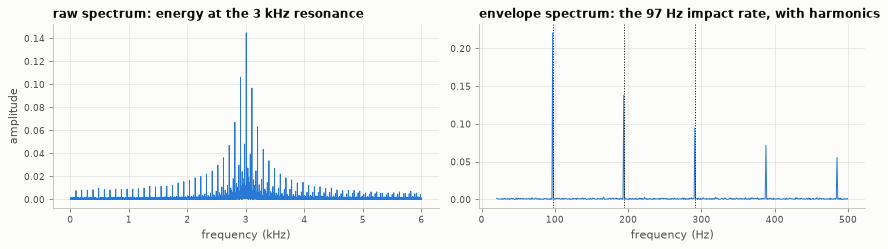

✓ spectrum, band-pass, low-pass, envelope and envelope spectrum match bearing_audit.dsp
✓ known-answer test: raw peak near 3 kHz, envelope peak at 97 Hz


In [8]:
# second-order sections, run forwards and backwards so the impacts don't shift in time
def bandpass(x, fs, lo, hi, order=4):
    sos = butter(order, [lo / (fs / 2), hi / (fs / 2)], btype="band", output="sos")
    return sosfiltfilt(sos, np.asarray(x, dtype=float))


def lowpass(x, fs, cutoff=config.BANDWIDTH_HZ, order=8):
    sos = butter(order, cutoff / (fs / 2), btype="low", output="sos")
    return sosfiltfilt(sos, np.asarray(x, dtype=float))


def envelope(x):
    return np.abs(hilbert(np.asarray(x, dtype=float)))


def envelope_spectrum(x, fs, band):
    return amplitude_spectrum(envelope(bandpass(x, fs, *band)), fs)


# impacts at fault_hz, each ringing a decaying 3 kHz resonance, in a little noise
# (the same signal the unit tests get from tests/conftest.py)
def synthetic_fault(fs=FS, seconds=2.0, fault_hz=97.0, resonance_hz=3_000.0, damping=600.0, noise=0.05, seed=0):
    n = int(fs * seconds)
    x = np.zeros(n)
    t = np.arange(int(0.01 * fs)) / fs
    ring = np.exp(-damping * t) * np.sin(2 * np.pi * resonance_hz * t)
    for t0 in np.arange(0, seconds, 1 / fault_hz):
        i = int(t0 * fs)
        x[i : i + ring[: n - i].size] += ring[: n - i]
    return x + noise * np.random.default_rng(seed).standard_normal(n)


xs = synthetic_fault()
f, a = amplitude_spectrum(xs, FS)
fe, ae = envelope_spectrum(xs, FS, (2_000, 4_000))
w = (fe > 20) & (fe < 500)
raw_peak, env_peak = f[np.argmax(a)], fe[w][np.argmax(ae[w])]
print(f"raw spectrum peaks at {raw_peak:.0f} Hz; envelope spectrum (20-500 Hz) peaks at {env_peak:.1f} Hz")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(f / 1000, a, color=plots.COLOR["IR"], lw=0.8)
ax[0].set(title="raw spectrum: energy at the 3 kHz resonance", xlabel="frequency (kHz)", ylabel="amplitude")
ax[1].plot(fe[w], ae[w], color=plots.COLOR["IR"], lw=0.9)
for k in (1, 2, 3):
    ax[1].axvline(97 * k, color=plots.INK, ls=":", lw=0.9)
ax[1].set(title="envelope spectrum: the 97 Hz impact rate, with harmonics", xlabel="frequency (Hz)")
fig.tight_layout()
plt.show()

# compare with the package on plain random noise
rng = np.random.default_rng(1)
z = rng.standard_normal(24_000)
check(
    "spectrum, band-pass, low-pass, envelope and envelope spectrum match bearing_audit.dsp",
    same(amplitude_spectrum(z, FS)[1], dsp.amplitude_spectrum(z, FS)[1])
    and same(bandpass(z, FS, 2_000, 4_900), dsp.bandpass(z, FS, 2_000, 4_900))
    and same(lowpass(z, FS), dsp.lowpass(z, FS, config.BANDWIDTH_HZ))
    and same(envelope(z), dsp.envelope(z))
    and same(envelope_spectrum(z, FS, (2_000, 4_900))[1], dsp.envelope_spectrum(z, FS, (2_000, 4_900))[1]),
)
check(
    "known-answer test: raw peak near 3 kHz, envelope peak at 97 Hz",
    abs(raw_peak - 3_000) <= 50 and abs(env_peak - 97) <= 1,
)

## 7. Choosing the band by measurement: spectral kurtosis

Which band holds the ringing? Instead of guessing, measure it. Spectral kurtosis
`SK(f) = E|X(t,f)|⁴ / (E|X(t,f)|²)² − 2` is about 0 for steady noise and large where a band is *bursty*,
which is exactly what repeated impacts make it. A simplified kurtogram computes SK with several STFT window
lengths (short windows test wide bands, long ones narrow bands) and keeps the band with the highest SK
between 500 Hz and 5 kHz. The project uses it two ways: `sk_max` as a feature, and a second physics rule
that demodulates in the SK-chosen band instead of the fixed 2–4.9 kHz band.

IR007_0: chosen band 4000-5000 Hz, SK 1.96
Normal_0: chosen band 3000-3500 Hz, SK 0.37


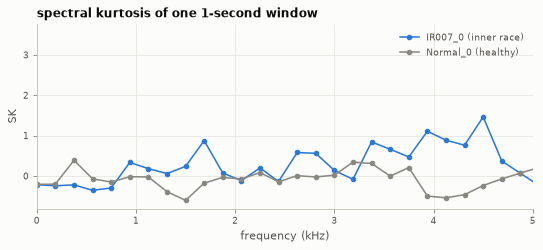

✓ spectral kurtosis and band selection match bearing_audit.dsp


In [9]:
# SK per frequency bin: about 0 for steady noise, large where the band is bursty
def spectral_kurtosis(x, fs, nperseg):
    f, _, zz = stft(
        np.asarray(x, dtype=float),
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=nperseg * 3 // 4,
        boundary=None,
        padded=False,
    )
    p = np.abs(zz) ** 2
    return f, np.mean(p**2, axis=1) / np.maximum(np.mean(p, axis=1) ** 2, 1e-30) - 2.0


# simplified kurtogram: each STFT bin becomes the band centre ± fs/nperseg; keep the highest SK
def select_band(x, fs, fmin=config.SK_FMIN_HZ, fmax=config.BANDWIDTH_HZ, npersegs=(16, 24, 32, 48, 64)):
    best = (-np.inf, (fmin, fmax))
    for n in npersegs:
        half = fs / n
        for fc, k in zip(*spectral_kurtosis(x, fs, n), strict=True):
            lo, hi = fc - half, fc + half
            if lo >= fmin and hi <= fmax and k > best[0] + 1e-12:
                best = (float(k), (float(lo), float(hi)))
    return best[1], best[0]


fig, ax = plt.subplots(figsize=(8, 3))
for name, fault in (("IR007_0", "IR"), ("Normal_0", "Normal")):
    win = lowpass(SIG[name]["x"][:FS], FS)
    fk, sk = spectral_kurtosis(win, FS, 64)
    ax.plot(fk / 1000, sk, marker="o", ms=4, lw=1.4, color=plots.COLOR[fault], label=f"{name} ({plots.NAME[fault]})")
    band, k = select_band(win, FS)
    print(f"{name}: chosen band {band[0]:.0f}-{band[1]:.0f} Hz, SK {k:.2f}")
ax.set(title="spectral kurtosis of one 1-second window", xlabel="frequency (kHz)", ylabel="SK", xlim=(0, 5))
ax.legend()
plt.show()

wins = [lowpass(SIG[n]["x"][:FS], FS) for n in ("IR007_0", "B014_2", "OR021@6_3", "Normal_1")]
check(
    "spectral kurtosis and band selection match bearing_audit.dsp",
    all(
        same(spectral_kurtosis(v, FS, 32)[1], dsp.spectral_kurtosis(v, FS, 32)[1])
        and select_band(v, FS) == dsp.select_band(v, FS, fmin=config.SK_FMIN_HZ, fmax=config.BANDWIDTH_HZ)
        for v in wins
    ),
)

## 8. Physics verification: is the fault line really there, in every faulty recording?

Before any model: for each of the 52 faulty recordings (full length), compute the envelope spectrum and
look within ±3 % of the predicted line, at *that recording's own* shaft speed. Prominence is the tallest
peak there divided by the median level around it: "does a line stand out *here*?", independent of how
loud the machine is. A line counts as present at prominence ≥ 10.

,recordings,line_present,median_prominence,median error % when present
fault,,,,
B,12,0,4.955,NaN
IR,12,12,143.536,0.220
OR,28,24,102.287,0.303


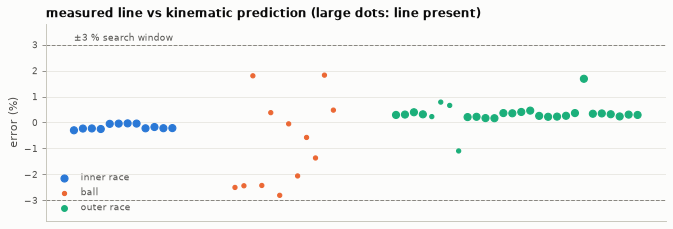

✓ physics summary matches reports/results/physics_summary.csv
✓ physics check matches reports/results/physics_check.csv


In [10]:
# tallest point within ±tol of the target, divided by the median level around it
def prominence(f, a, target, ref_halfwidth, tol=config.PEAK_TOL):
    search = (f >= target * (1 - tol)) & (f <= target * (1 + tol))
    ref = (f >= target - ref_halfwidth) & (f <= target + ref_halfwidth)
    if not search.any() or not ref.any():
        return float("nan"), float("nan")
    i = int(np.argmax(a[search]))
    return float(f[search][i]), float(a[search][i] / max(float(np.median(a[ref])), 1e-30))


rows = []
for r in catalog.FAULTED:
    x = lowpass(SIG[r.name]["x"], FS)
    shaft = SIG[r.name]["rpm"] / 60
    sig = bearing.SIGNATURE[r.fault]
    pred = fault_frequencies(shaft)[sig]
    f, a = envelope_spectrum(x, FS, config.ENVELOPE_BAND_HZ)
    meas, prom = prominence(f, a, pred, 0.5 * pred)
    band, sk = select_band(x, FS)
    _, prom_sk = prominence(*envelope_spectrum(x, FS, band), pred, 0.5 * pred)
    rows.append(
        {
            "recording": r.name,
            "bearing": r.bearing,
            "fault": r.fault,
            "core": r.core,
            "signature": sig,
            "predicted_hz": pred,
            "measured_hz": meas,
            "measured_over_predicted": meas / pred,
            "prominence": prom,
            "present": prom >= config.PRESENT_PROMINENCE,
            "prominence_sk_band": prom_sk,
        }
    )
phys = pd.DataFrame(rows)
phys_summary = phys.groupby("fault").agg(
    recordings=("present", "size"), line_present=("present", "sum"), median_prominence=("prominence", "median")
)
phys_summary["median error % when present"] = (
    phys[phys.present].groupby("fault").measured_over_predicted.apply(lambda v: float((v - 1).abs().median() * 100))
)
display(phys_summary)

fig, ax = plt.subplots(figsize=(10, 3.2))
for k, (fault, g) in enumerate(phys.groupby("fault", sort=False)):
    ax.scatter(
        np.arange(len(g)) + 18 * k,
        100 * (g.measured_over_predicted - 1),
        s=np.where(g.present, 40, 14),
        color=plots.COLOR[fault],
        label=plots.NAME[fault],
        zorder=3,
    )
for lim in (-3, 3):
    ax.axhline(lim, color=plots.MUTED, ls="--", lw=0.9)
ax.text(0, 3.15, "±3 % search window", fontsize=8, color=plots.INK2)
ax.set(
    title="measured line vs kinematic prediction (large dots: line present)",
    ylabel="error (%)",
    xticks=[],
    ylim=(-3.8, 3.8),
)
ax.legend(loc="lower left")
plt.show()

ref = committed("physics_check.csv")
ref_summary = committed("physics_summary.csv").set_index("fault")
check(
    "physics summary matches reports/results/physics_summary.csv",
    same(
        phys_summary[["recordings", "line_present", "median_prominence", "median error % when present"]],
        ref_summary.loc[
            phys_summary.index, ["recordings", "present", "median_prominence", "median_abs_error_pct_when_present"]
        ],
    ),
)
check(
    "physics check matches reports/results/physics_check.csv",
    phys.recording.tolist() == ref.recording.tolist()
    and (phys.present == ref.present).all()
    and same(
        phys[["predicted_hz", "measured_hz", "prominence", "prominence_sk_band"]],
        ref[["predicted_hz", "measured_hz", "prominence", "prominence_sk_band"]],
    ),
)

Where a line is present it sits within a fraction of a percent of the prediction (the last
column), so the kinematics, the sampling rates and the rpm values are all right. Every inner-race recording
shows its line, and most outer-race ones do. No ball recording shows 2 × BSF, which is already a
hint of where the models will struggle.

## 9. Windows and features: 24 numbers per second of vibration

Each recording is cut into non-overlapping one-second windows (1 Hz resolution in the envelope spectrum,
enough to separate BPFO ≈ 107 Hz, 2 × BSF ≈ 141 Hz and BPFI ≈ 162 Hz). Every feature uses one window
only, so no information crosses a window boundary. Each window is low-passed at 5 kHz first (part 4).

| group | features |
|---|---|
| time domain | RMS, kurtosis, skewness, crest factor, peak-to-peak |
| spectral | share of energy in 0–0.5, 0.5–1, 1–2, 2–3, 3–4, 4–5 kHz; SK maximum and where it is |
| envelope | log10 prominence at BPFI, BPFO, 2 × BSF (1st harmonic, and mean of the first 3) |
| envelope, diagnoser only | inner-race sidebands at BPFI ± shaft speed; ball line at 1 × BSF |
| envelope, SK band | log10 prominence at the three lines, demodulating in the SK-chosen band |

In [11]:
BANDS = [(0, 500), (500, 1000), (1000, 2000), (2000, 3000), (3000, 4000), (4000, 5000)]
SIGNATURES = ("BPFI", "BPFO", "2xBSF")


def time_features(x):
    x = x - x.mean()
    rms = float(np.sqrt(np.mean(x**2)))
    zz = x / rms
    return {
        "rms": rms,
        "kurtosis": float(np.mean(zz**4)),
        "skewness": float(np.mean(zz**3)),
        "crest": float(np.max(np.abs(x)) / rms),
        "p2p": float(np.ptp(x)),
    }


def spectral_features(x, fs, bandwidth):
    f, a = amplitude_spectrum(x, fs)
    p = a**2
    total = p[f <= bandwidth].sum()
    out = {f"band_{lo}_{hi}": float(np.log10(p[(f >= lo) & (f < hi)].sum() / total)) for lo, hi in BANDS}
    fk, sk = spectral_kurtosis(x, fs, 64)
    ok = (fk >= config.SK_FMIN_HZ) & (fk <= bandwidth)
    j = int(np.argmax(sk[ok]))
    return out | {"sk_max": float(sk[ok][j]), "sk_freq": float(fk[ok][j])}


def envelope_features(x, fs, shaft, band, prefix, extended=False):
    f, a = envelope_spectrum(x, fs, band)
    q = fault_frequencies(shaft)
    out = {}
    for s in SIGNATURES:
        proms = [prominence(f, a, k * q[s], 0.5 * q[s])[1] for k in range(1, config.N_HARMONICS + 1)]
        out[f"{prefix}_{s}_h1"] = float(np.log10(proms[0]))
        out[f"{prefix}_{s}_hm"] = float(np.log10(np.mean(proms)))
    # two extra inputs for the physics diagnoser: BPFI ± shaft-speed sidebands and the 1 x BSF line
    if extended:
        sb = [prominence(f, a, q["BPFI"] + dd, 0.5 * shaft)[1] for dd in (-shaft, shaft)]
        out[f"{prefix}_BPFI_sb"] = float(np.log10(np.mean(sb)))
        out[f"{prefix}_BSF_h1"] = float(np.log10(prominence(f, a, q["BSF"], 0.5 * q["BSF"])[1]))
    return out


def window_features(x, fs, shaft, bandwidth=config.BANDWIDTH_HZ):
    x = lowpass(x, fs, bandwidth)
    env_band = (config.ENVELOPE_BAND_HZ[0], min(config.ENVELOPE_BAND_HZ[1], bandwidth - 100.0))
    feats = time_features(x) | spectral_features(x, fs, bandwidth)
    feats |= envelope_features(x, fs, shaft, env_band, "env", extended=True)
    # the SK band is picked per window, and only its first-harmonic lines are kept
    sk_band, _ = select_band(x, fs, fmax=bandwidth)
    feats |= {k: v for k, v in envelope_features(x, fs, shaft, sk_band, "envsk").items() if k.endswith("_h1")}
    return feats


def feature_table(bandwidth=config.BANDWIDTH_HZ):
    rows = []
    for r in catalog.CORE:
        x, rpm = SIG[r.name]["x"], SIG[r.name]["rpm"]
        n = int(config.WINDOW_S * FS)
        for i in range(x.size // n):
            rows.append(
                {
                    "recording": r.name,
                    "window": i,
                    "bearing": r.bearing,
                    "fault": r.fault,
                    "label10": r.label10,
                    "size_mils": r.size_mils,
                    "load_hp": r.load_hp,
                    "rpm": rpm,
                    **window_features(x[i * n : (i + 1) * n], FS, rpm / 60, bandwidth),
                }
            )
    return pd.DataFrame(rows)


t = time.time()
df = feature_table()
print(
    f"{len(df)} windows x {df.shape[1]} columns from {df.recording.nunique()} recordings of "
    f"{df.bearing.nunique()} bearings, in {time.time() - t:.0f} s"
)
display(df.groupby("fault").size().rename("windows").to_frame().T)

one = SIG["IR007_0"]["x"][:FS]
check(
    "one window's features match bearing_audit.features.window_features",
    window_features(one, FS, SIG["IR007_0"]["rpm"] / 60)
    == features.window_features(one, FS, SIG["IR007_0"]["rpm"] / 60),
)
ref = committed("features.csv")
check(
    "feature table matches reports/results/features.csv (395 windows, 32 columns)",
    list(df.columns) == list(ref.columns)
    and df.shape == ref.shape
    and (df.select_dtypes(exclude="number").to_numpy() == ref.select_dtypes(exclude="number").to_numpy()).all()
    and same(df.select_dtypes("number"), ref.select_dtypes("number")),
)

395 windows x 32 columns from 40 recordings of 10 bearings, in 5 s


fault,B,IR,Normal,OR
windows,120,120,35,120


✓ one window's features match bearing_audit.features.window_features
✓ feature table matches reports/results/features.csv (395 windows, 32 columns)


## 10. Two models: a physics rule and a random forest

The physics rule is the baseline the ML model has to beat. For each window it takes the three
log-prominences at BPFI, BPFO and 2 × BSF. If none of them is above a threshold the window is Normal;
otherwise it gets the fault whose line stands out most. That threshold is the only thing it learns (the
best macro-F1 on the training data, searched from 1× to 100×). It can't memorise a recording, because all
it sees is three numbers tied to the machine's geometry.

The random forest uses the 19 time, spectral and fixed-band envelope features: 300 trees, balanced class
weights, and no tuning on purpose. No hyper-parameter search means no search that could leak.

In [12]:
FAULT_OF = {"BPFI": "IR", "BPFO": "OR", "2xBSF": "B"}


class EnvelopeRule(ClassifierMixin, BaseEstimator):
    def __init__(self, columns=("env_BPFI_h1", "env_BPFO_h1", "env_2xBSF_h1")):
        self.columns = columns

    def _decide(self, s, threshold):
        faults = np.array([FAULT_OF[c.split("_")[1]] for c in self.columns])
        out = faults[np.argmax(s, axis=1)].astype(object)
        out[s.max(axis=1) < threshold] = "Normal"
        return out

    def fit(self, X, y):
        s, y = X[list(self.columns)].to_numpy(dtype=float), np.asarray(y)
        self.classes_ = np.unique(y)
        grid = np.linspace(0.0, 2.0, 201)  # log10 prominence, so thresholds from 1x to 100x
        scores = [f1_score(y, self._decide(s, t), average="macro", zero_division=0) for t in grid]
        self.threshold_ = float(grid[int(np.argmax(scores))])
        return self

    def predict(self, X):
        return self._decide(X[list(self.columns)].to_numpy(dtype=float), self.threshold_)


def make_forest(seed=config.RANDOM_STATE):
    return RandomForestClassifier(
        n_estimators=300, min_samples_leaf=2, class_weight="balanced", random_state=seed, n_jobs=-1
    )


FEATURES = [
    "rms",
    "kurtosis",
    "skewness",
    "crest",
    "p2p",
    *[f"band_{lo}_{hi}" for lo, hi in BANDS],
    "sk_max",
    "sk_freq",
    *[f"env_{s}_{h}" for s in SIGNATURES for h in ("h1", "hm")],
]
SK_RULE = [f"envsk_{s}_h1" for s in SIGNATURES]
MODELS = {
    "forest": (make_forest(), FEATURES),
    "rule_fixed_band": (EnvelopeRule(), ["env_BPFI_h1", "env_BPFO_h1", "env_2xBSF_h1"]),
    "rule_sk_band": (EnvelopeRule(tuple(SK_RULE)), SK_RULE),
}
check("the 19 forest features are the package's features.FEATURES", FEATURES == features.FEATURES)
check("forest settings match evaluate.forest()", make_forest().get_params() == evaluate.forest().get_params())
check(
    "rule threshold on all windows matches rules.EnvelopeRule",
    EnvelopeRule().fit(df, df.fault).threshold_ == rules.EnvelopeRule().fit(df, df.fault).threshold_,
)

✓ the 19 forest features are the package's features.FEATURES
✓ forest settings match evaluate.forest()


✓ rule threshold on all windows matches rules.EnvelopeRule


## 11. The leakage audit: the same models, three ways of splitting the data

There are three nested units, window < recording < bearing, and a test is only as honest as the
largest unit it keeps apart:

- A. Random windows (5 folds). Windows of the same recording land on both sides. This tests whether the
  model can recognise a recording it has already seen; it's the split behind most "99 %" CWRU results.
- B. Leave one load out (4 folds). No recording is shared, but every bearing is, at another load. This
  tests whether it can recognise a bearing it has already seen.
- C. Unseen bearing, unseen load (12 folds). For each fault size s and load l: train on the other two
  sizes at the other three loads, test on size s at load l. The test bearings were never seen, at any load.
  CWRU has only one healthy bearing, so the healthy class is held out by load only.

✓ all 21 folds of protocols A, B and C match bearing_audit.protocols


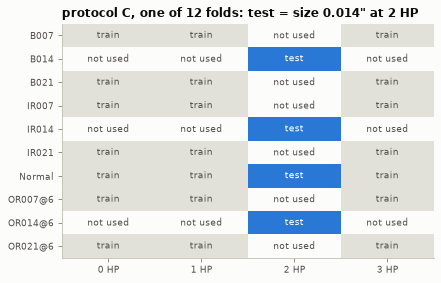

In [13]:
def window_random(df, label="fault", n_splits=5):
    yield from StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=config.RANDOM_STATE).split(
        np.zeros(len(df)), df[label]
    )


def leave_one_load_out(df, label=None):
    for load in sorted(df.load_hp.unique()):
        test = df.load_hp.to_numpy() == load
        yield np.flatnonzero(~test), np.flatnonzero(test)


# protocol C: test one fault size at one load, train on the other sizes at the other loads.
# There's only one healthy bearing, so healthy windows are split by load alone.
def unseen_bearing(df, label=None):
    normal, size, load = df.fault.eq("Normal").to_numpy(), df.size_mils.to_numpy(), df.load_hp.to_numpy()
    for s in sorted(np.unique(size[~normal])):
        for ld in sorted(np.unique(load)):
            test = (load == ld) & (normal | (size == s))
            train = (load != ld) & (normal | (size != s))
            yield np.flatnonzero(train), np.flatnonzero(test)


PROTOCOLS = {
    "A_window_random": window_random,
    "B_leave_one_load_out": leave_one_load_out,
    "C_unseen_bearing": unseen_bearing,
}
check(
    "all 21 folds of protocols A, B and C match bearing_audit.protocols",
    all(
        len(list(mine(df, "fault"))) == len(list(theirs(df, "fault")))
        and all(
            np.array_equal(a, b)
            for fa, fb in zip(mine(df, "fault"), theirs(df, "fault"), strict=True)
            for a, b in zip(fa, fb, strict=True)
        )
        for mine, theirs in zip(PROTOCOLS.values(), protocols.PROTOCOLS.values(), strict=True)
    ),
)

# Draw one protocol-C fold: test size 0.014", test load 2 HP.
fold = list(unseen_bearing(df))[6]  # folds go size first: 0.007" at 0-3 HP, then 0.014", ...
role = pd.Series("not used", index=df.index)
role.iloc[fold[0]], role.iloc[fold[1]] = "train", "test"
grid = df.assign(role=role).groupby(["bearing", "load_hp"]).role.first().unstack()
codes = {"not used": 0, "train": 1, "test": 2}
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.imshow(
    grid.map(codes.get).to_numpy(dtype=float),
    cmap=ListedColormap([plots.SURFACE, plots.GRID, plots.COLOR["IR"]]),
    vmin=0,
    vmax=2,
    aspect="auto",
)
for (i, j), v in np.ndenumerate(grid.to_numpy()):
    ax.text(j, i, v, ha="center", va="center", fontsize=8, color="white" if v == "test" else plots.INK2)
ax.set(
    xticks=range(4),
    xticklabels=[f"{c} HP" for c in grid.columns],
    yticks=range(len(grid)),
    yticklabels=grid.index,
    title='protocol C, one of 12 folds: test = size 0.014" at 2 HP',
)
ax.grid(False)
plt.show()

Now evaluate every model under every protocol. Macro-F1 is computed per fold and averaged; recall per class
is pooled over all folds. The 10-class task (fault type and size) is only run under A and B: under C,
the held-out size never appears in training, so it can't be predicted.

11 evaluations in 36 s


,task,protocol,model,folds,mean_macro_f1,sd_macro_f1,pooled_accuracy,recall_Normal,recall_IR,recall_B,recall_OR
0,type4,A_window_random,forest,5,1.000,0.000,1.000,1.000,1.000,1.000,1.000
1,type4,A_window_random,rule_fixed_band,5,0.650,0.050,0.668,0.800,1.000,0.283,0.683
2,type4,A_window_random,rule_sk_band,5,0.580,0.026,0.646,0.686,1.000,0.217,0.708
3,type4,B_leave_one_load_out,forest,4,0.994,0.011,0.992,1.000,1.000,1.000,0.975
4,type4,B_leave_one_load_out,rule_fixed_band,4,0.645,0.055,0.668,0.800,1.000,0.283,0.683
5,type4,B_leave_one_load_out,rule_sk_band,4,0.573,0.044,0.643,0.657,1.000,0.217,0.708
6,type4,C_unseen_bearing,forest,12,0.732,0.217,0.774,1.000,0.775,0.883,0.467
7,type4,C_unseen_bearing,rule_fixed_band,12,0.603,0.102,0.671,0.829,1.000,0.192,0.683
8,type4,C_unseen_bearing,rule_sk_band,12,0.603,0.113,0.669,0.781,1.000,0.200,0.708
9,type_size10,A_window_random,forest,5,0.997,0.005,0.997,NaN,NaN,NaN,NaN


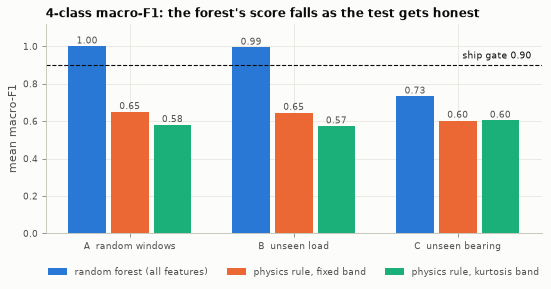

✓ all 11 audit results match reports/results/audit_summary.csv


In [14]:
TYPE_ORDER = ["Normal", "IR", "B", "OR"]
TASKS = {"type4": "fault", "type_size10": "label10"}
OOF = {}  # protocol C out-of-fold predictions, used again in part 13


def evaluate_model(task, protocol, model):
    label = TASKS[task]
    est, cols = MODELS[model]
    y = df[label].to_numpy()
    fold_f1, yt, yp = [], [], []  # macro-F1 per fold; recall is pooled over all folds
    for k, (train, test) in enumerate(PROTOCOLS[protocol](df, label)):
        m = clone(est).fit(df.iloc[train][cols], y[train])
        p = m.predict(df.iloc[test][cols])
        fold_f1.append(f1_score(y[test], p, labels=np.unique(y[test]), average="macro", zero_division=0))
        yt.append(y[test])
        yp.append(p)
        if task == "type4" and protocol == "C_unseen_bearing":
            OOF.setdefault(model, []).append(
                df.iloc[test][["recording", "window", "bearing", "fault"]].assign(pred=p, fold=k)
            )
    yt, yp = np.concatenate(yt), np.concatenate(yp)
    labels = TYPE_ORDER if task == "type4" else sorted(np.unique(y), key=lambda s: (s != "Normal", s))
    recall = dict(zip(labels, recall_score(yt, yp, labels=labels, average=None, zero_division=0), strict=True))
    return {
        "task": task,
        "protocol": protocol,
        "model": model,
        "folds": len(fold_f1),
        "mean_macro_f1": float(np.mean(fold_f1)),
        "sd_macro_f1": float(np.std(fold_f1)),
        "pooled_accuracy": float(np.mean(yt == yp)),
        **({f"recall_{k}": v for k, v in recall.items()} if task == "type4" else {}),
        "confusion": confusion_matrix(yt, yp, labels=labels),
    }


t = time.time()
runs = []
for task in TASKS:
    for protocol in PROTOCOLS:
        if task == "type_size10" and protocol == "C_unseen_bearing":
            continue
        for model in MODELS:
            if model != "forest" and task != "type4":
                continue
            runs.append(evaluate_model(task, protocol, model))
audit = pd.DataFrame(runs).drop(columns="confusion")
print(f"{len(runs)} evaluations in {time.time() - t:.0f} s")
display(audit.round(3))

fig, ax = plt.subplots(figsize=(8, 3.4))
four = audit[audit.task == "type4"]
width = 0.26
for k, (model, g) in enumerate(four.groupby("model", sort=False)):
    xs = np.arange(3) + (k - 1) * width
    ax.bar(xs, g.mean_macro_f1, width - 0.03, color=plots.MODEL_COLOR[model], label=plots.MODEL_NAME[model])
    for xv, v in zip(xs, g.mean_macro_f1, strict=True):
        ax.text(xv, v + 0.015, f"{v:.2f}", ha="center", fontsize=8, color=plots.INK2)
ax.axhline(config.GATE_MIN_MACRO_F1, color=plots.INK, ls="--", lw=1)
ax.text(2.45, config.GATE_MIN_MACRO_F1 + 0.035, "ship gate 0.90", fontsize=8, color=plots.INK, ha="right")
ax.set(
    xticks=range(3),
    xticklabels=[plots.PROTO_NAME[p] for p in PROTOCOLS],
    ylabel="mean macro-F1",
    ylim=(0, 1.12),
    title="4-class macro-F1: the forest's score falls as the test gets honest",
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
plt.show()

ref = committed("audit_summary.csv")
mine = audit.round(3).set_index(["task", "protocol", "model"])
theirs = ref.set_index(["task", "protocol", "model"]).loc[mine.index]
check(
    "all 11 audit results match reports/results/audit_summary.csv",
    same(mine[theirs.columns].to_numpy(dtype=float), theirs.to_numpy(dtype=float), rtol=0, atol=5e-4),
)

## 12. The pre-registered ship gate

Fixed before the first audit run: a model ships only if, under protocol C, its mean macro-F1
is at least 0.90 and every class's pooled recall is at least 0.80.

In [15]:
gate_rows = []
for r in runs:
    if r["task"] == "type4" and r["protocol"] == "C_unseen_bearing":
        recalls = {k: r[f"recall_{k}"] for k in TYPE_ORDER}
        worst = min(recalls, key=recalls.get)
        gate_rows.append(
            {
                "model": r["model"],
                "mean_macro_f1": r["mean_macro_f1"],
                "worst_class": worst,
                "worst_recall": recalls[worst],
                "passed": r["mean_macro_f1"] >= config.GATE_MIN_MACRO_F1
                and recalls[worst] >= config.GATE_MIN_CLASS_RECALL,
            }
        )
gates = pd.DataFrame(gate_rows)
display(gates)
ship = bool(gates.passed.any())
print("ship:", ship)
ref = committed("gate.json")
check(
    "gate decision matches reports/results/gate.json (nothing ships)",
    ship == ref["ship"]
    and gates.passed.tolist() == [c["passed"] for c in ref["candidates"]]
    and same(gates.mean_macro_f1, [c["mean_macro_f1"] for c in ref["candidates"]]),
)

,model,mean_macro_f1,worst_class,worst_recall,passed
0,forest,0.732,OR,0.467,False
1,rule_fixed_band,0.603,B,0.192,False
2,rule_sk_band,0.603,B,0.200,False


ship: False
✓ gate decision matches reports/results/gate.json (nothing ships)


## 13. Why the forest fails on unseen bearings

Per-bearing accuracy under protocol C, and the forest's confusion matrix, show what it has learned: which
bearing a signal comes from, not which fault it has. Faced with a bearing it has never seen, it
often answers "ball".

,random forest (all features),"physics rule, fixed band","physics rule, kurtosis band"
bearing,,,
B007,1.000,0.075,0.175
B014,1.000,0.350,0.300
B021,0.650,0.150,0.125
IR007,1.000,1.000,1.000
IR014,0.325,1.000,1.000
IR021,1.000,1.000,1.000
Normal,1.000,0.829,0.781
OR007@6,0.675,1.000,1.000
OR014@6,0.000,0.050,0.125


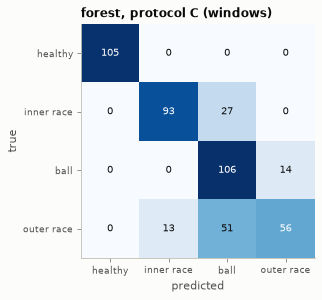

✓ per-bearing accuracy matches reports/results/per_bearing_protocol_C.csv
✓ every protocol-C window prediction matches reports/results/predictions_protocol_C.csv


In [16]:
preds = None
for model, parts in OOF.items():
    p = pd.concat(parts, ignore_index=True).rename(columns={"pred": model})
    preds = p if preds is None else preds.merge(p, on=["recording", "window", "bearing", "fault", "fold"])
per_bearing = pd.DataFrame({m: preds[m].eq(preds.fault).groupby(preds.bearing).mean() for m in MODELS})
display(per_bearing.rename(columns=plots.MODEL_NAME))

cm = next(
    r["confusion"]
    for r in runs
    if r["task"] == "type4" and r["protocol"] == "C_unseen_bearing" and r["model"] == "forest"
)
fig, ax = plt.subplots(figsize=(4.6, 3.8))
ax.imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, v, ha="center", va="center", fontsize=9, color="white" if v > cm.max() / 2 else plots.INK)
names = [plots.NAME[k] for k in TYPE_ORDER]
ax.set(
    xticks=range(4),
    xticklabels=names,
    yticks=range(4),
    yticklabels=names,
    xlabel="predicted",
    ylabel="true",
    title="forest, protocol C (windows)",
)
ax.grid(False)
plt.show()

ref = committed("per_bearing_protocol_C.csv").set_index("bearing")
check("per-bearing accuracy matches reports/results/per_bearing_protocol_C.csv", same(per_bearing[ref.columns], ref))
ref = committed("predictions_protocol_C.csv").sort_values(["fold", "recording", "window"]).reset_index(drop=True)
mine = preds.sort_values(["fold", "recording", "window"]).reset_index(drop=True)
check(
    "every protocol-C window prediction matches reports/results/predictions_protocol_C.csv",
    all((mine[m].to_numpy() == ref[m].to_numpy()).all() for m in MODELS),
)

## 14. Post-hoc robustness checks (added after the first run, never part of the gate)

- Ablation: which feature groups carry over to unseen bearings, and which only identify the bearing? In
  the core set each 10-class label *is* one physical bearing, so 10-class accuracy under protocol B measures
  how well a feature group recognises a bearing it has seen.
- Seed sweep: the gate uses seed 0. How much of any single number is random-seed noise?
- Bandwidth sensitivity: repeat protocol C with a stricter 4.7 kHz low-pass. If the results barely move,
  the remaining recorder difference in the 5.0–5.25 kHz transition band isn't driving them.

In [17]:
def protocol_c(data, cols, est):
    parts = []
    for k, (train, test) in enumerate(unseen_bearing(data)):
        m = clone(est).fit(data.iloc[train][cols], data.fault.to_numpy()[train])
        parts.append(data.iloc[test][["bearing", "fault"]].assign(pred=m.predict(data.iloc[test][cols]), fold=k))
    return pd.concat(parts, ignore_index=True)


def mean_fold_f1(p):
    return float(
        np.mean(
            [
                f1_score(g.fault, g.pred, labels=np.unique(g.fault), average="macro", zero_division=0)
                for _, g in p.groupby("fold")
            ]
        )
    )


# post-hoc only: nothing in this cell feeds the gate
if RUN_POSTHOC:
    t = time.time()
    groups_ = {"all features": FEATURES, "time + spectral only": FEATURES[:13], "envelope only": FEATURES[13:]}
    ablation = []
    for name, cols in groups_.items():
        hits = [
            clone(make_forest()).fit(df.iloc[tr][cols], df.label10.to_numpy()[tr]).predict(df.iloc[te][cols])
            == df.label10.to_numpy()[te]
            for tr, te in leave_one_load_out(df)
        ]
        ablation.append(
            {
                "features": name,
                "protocol C macro-F1": mean_fold_f1(protocol_c(df, cols, make_forest())),
                "bearing identity accuracy (B)": float(np.concatenate(hits).mean()),
            }
        )
    ablation = pd.DataFrame(ablation)
    display(ablation)

    seeds = [mean_fold_f1(protocol_c(df, FEATURES, make_forest(seed))) for seed in range(10)]
    print(f"forest, protocol C, seeds 0-9: {min(seeds):.3f} to {max(seeds):.3f}, mean {np.mean(seeds):.3f}")

    df47 = feature_table(bandwidth=4_700.0)
    bw = {m: mean_fold_f1(protocol_c(df47, cols, est)) for m, (est, cols) in MODELS.items()}
    print("protocol C at a 4.7 kHz low-pass:", {k: round(v, 3) for k, v in bw.items()})
    print(f"post-hoc checks: {time.time() - t:.0f} s")

    ref_ab = pd.DataFrame(committed("ablation_posthoc.json"))
    ref_seed, ref_bw = committed("seed_sweep_posthoc.json"), committed("bandwidth_sensitivity_posthoc.json")
    check(
        "feature groups match evaluate.ABLATION_GROUPS",
        all(groups_[k] == v for k, v in evaluate.ABLATION_GROUPS.items()),
    )
    check(
        "ablation matches reports/results/ablation_posthoc.json",
        same(ablation["protocol C macro-F1"], ref_ab.protocol_C_mean_macro_f1)
        and same(ablation["bearing identity accuracy (B)"], ref_ab.bearing_identity_accuracy_protocol_B),
    )
    check("seed sweep matches reports/results/seed_sweep_posthoc.json", same(seeds, ref_seed["mean_macro_f1"]))
    check(
        "4.7 kHz sensitivity matches reports/results/bandwidth_sensitivity_posthoc.json",
        same([bw[m] for m in MODELS], [ref_bw[m] for m in MODELS]),
    )
else:
    print("skipped (RUN_POSTHOC = False)")

,features,protocol C macro-F1,bearing identity accuracy (B)
0,all features,0.732,0.975
1,time + spectral only,0.500,0.959
2,envelope only,0.514,0.785


forest, protocol C, seeds 0-9: 0.641 to 0.737, mean 0.702


protocol C at a 4.7 kHz low-pass: {'forest': 0.736, 'rule_fixed_band': 0.6, 'rule_sk_band': 0.618}
post-hoc checks: 138 s
✓ feature groups match evaluate.ABLATION_GROUPS
✓ ablation matches reports/results/ablation_posthoc.json
✓ seed sweep matches reports/results/seed_sweep_posthoc.json
✓ 4.7 kHz sensitivity matches reports/results/bandwidth_sensitivity_posthoc.json


## 15. Industrial evaluation: judge the systems the way a plant does

A maintenance team doesn't look at window-level F1. It gets an alarm, then a diagnosis. The industrial
evaluation (pre-registered in `docs/industrial-preregistration.md`, protocol C only) changes three things:

1. Three answers per window: Healthy, a named fault (IR / B / OR), or Undiagnosed (damage found, but not
   which part). A wrong name sends the technician to the wrong part.
2. One decision per recording: a recording alarms if at least half its windows do. It gets a fault name
   if one fault holds at least half of its alarm windows with no tie; otherwise it's Undiagnosed.
3. Plant metrics: false-alarm rate (must be 0), detection rate, coverage (how often a detected fault gets
   a name) and diagnosis precision (how often that name is right), plus an illustrative cost per outcome.

The physics diagnoser learns nothing except thresholds, and each one is the highest value that quantity
reached on any healthy training window. It raises an alarm if any fault line, or any scale-free broadband
indicator (kurtosis, crest factor, SK maximum), goes above anything the healthy machine ever showed. It
names a fault only if that fault's own line does. An inner-race name also needs the shaft-rate sidebands;
they confirm a diagnosis but never raise an alarm on their own. (The first run of this evaluation got that
last rule wrong. It was fixed to match the pre-registered design, and both runs are reported.)

In [18]:
FAULTS = ("IR", "B", "OR")
OUTCOMES = ("correct", "false_alarm", "missed", "wrong_type", "undiagnosed")


class PhysicsDiagnoser(BaseEstimator):
    BROADBAND = ("kurtosis", "crest", "sk_max")

    def _scores(self, X):
        return pd.DataFrame(
            {
                "IR": X["env_BPFI_h1"].to_numpy(),
                "IR_sb": X["env_BPFI_sb"].to_numpy(),
                "OR": X["env_BPFO_h1"].to_numpy(),
                "B": np.maximum(X["env_2xBSF_h1"].to_numpy(), X["env_BSF_h1"].to_numpy()),
                **{k: X[k].to_numpy() for k in self.BROADBAND},
            }
        )

    def fit(self, X, y):
        # each threshold is the highest value seen on any healthy training window
        self.thresholds_ = self._scores(X)[np.asarray(y) == "Normal"].max()
        return self

    def predict(self, X):
        s, t = self._scores(X), self.thresholds_
        over = s.gt(t)
        # alarm on any fault line or broadband indicator; the sidebands only confirm an IR name
        alarm = over[["IR", "OR", "B", *self.BROADBAND]].any(axis=1).to_numpy()
        candidate = {"IR": over["IR"] & over["IR_sb"], "OR": over["OR"], "B": over["B"]}
        margin = pd.DataFrame({k: (s[k] - t[k]).where(candidate[k], -np.inf) for k in FAULTS})
        named = np.isfinite(margin.max(axis=1)).to_numpy()
        return np.where(~alarm, "Healthy", np.where(named, margin.idxmax(axis=1).to_numpy(), "Undiagnosed")).astype(
            object
        )


class AbstainingForest(BaseEstimator):
    # Same forest as in the audit, but it can say "Undiagnosed" when its top probability is under 0.5.
    def fit(self, X, y):
        self.model_ = make_forest().fit(X, y)
        return self

    def predict(self, X):
        p = self.model_.predict_proba(X)
        top = self.model_.classes_[np.argmax(p, axis=1)]
        out = np.where(top == "Normal", "Healthy", top).astype(object)
        out[p.max(axis=1) < config.ABSTAIN_BELOW] = "Undiagnosed"
        return out


class ForcedChoice(BaseEstimator):
    # One of the audit models, with Normal renamed to Healthy so it fits the three states.
    def __init__(self, model="forest"):
        self.model = model

    def fit(self, X, y):
        est, self.cols_ = MODELS[self.model]
        self.est_ = clone(est).fit(X[self.cols_], y)
        return self

    def predict(self, X):
        p = self.est_.predict(X[self.cols_])
        return np.where(p == "Normal", "Healthy", p).astype(object)


DIAGNOSER_FEATURES = [
    "env_BPFI_h1",
    "env_BPFI_sb",
    "env_BPFO_h1",
    "env_2xBSF_h1",
    "env_BSF_h1",
    "kurtosis",
    "crest",
    "sk_max",
]
SYSTEMS = {
    "forest": (lambda: ForcedChoice("forest"), None),
    "rule": (lambda: ForcedChoice("rule_fixed_band"), None),
    "forest_abstain": (AbstainingForest, FEATURES),
    "physics_diagnoser": (PhysicsDiagnoser, DIAGNOSER_FEATURES),
}

t = time.time()
parts, thresholds = [], []
y = df.fault.to_numpy()
for k, (train, test) in enumerate(unseen_bearing(df)):
    part = df.iloc[test][["recording", "window", "bearing", "fault", "size_mils", "load_hp"]].assign(fold=k)
    for name, (make, cols) in SYSTEMS.items():
        Xtr, Xte = (df.iloc[train], df.iloc[test]) if cols is None else (df.iloc[train][cols], df.iloc[test][cols])
        est = make().fit(Xtr, y[train])
        part[name] = est.predict(Xte)
        if name == "physics_diagnoser":
            thresholds.append(est.thresholds_)
    parts.append(part)
states = pd.concat(parts, ignore_index=True)
print(f"12 folds x 4 systems in {time.time() - t:.0f} s")

12 folds x 4 systems in 20 s


In [19]:
# a recording alarms if at least half its windows do, and gets a fault name if one fault
# holds at least half of the alarm windows with no tie
def recording_decision(s):
    s = pd.Series(s)
    alarm = s != "Healthy"
    if alarm.mean() < config.ALARM_SHARE:
        return "Healthy"
    counts = s[alarm & s.isin(FAULTS)].value_counts()
    enough = len(counts) > 0 and counts.iloc[0] / alarm.sum() >= config.DIAGNOSIS_SHARE
    untied = len(counts) == 1 or (len(counts) > 1 and counts.iloc[0] > counts.iloc[1])
    return str(counts.index[0]) if enough and untied else "Undiagnosed"


def outcome(truth, decision):
    if truth == "Normal":
        return "correct" if decision == "Healthy" else "false_alarm"
    if decision == "Healthy":
        return "missed"
    return "undiagnosed" if decision == "Undiagnosed" else ("correct" if decision == truth else "wrong_type")


def plant_metrics(truth, decision, cost=config.OUTCOME_COST):
    truth, decision = np.asarray(truth), np.asarray(decision)
    healthy, alarm, named = truth == "Normal", decision != "Healthy", np.isin(decision, FAULTS)
    detected = ~healthy & alarm
    outs = [outcome(a, b) for a, b in zip(truth, decision, strict=True)]
    return {
        "false_alarm_rate": alarm[healthy].mean(),
        "detection_rate": alarm[~healthy].mean(),
        "coverage": named[detected].mean(),
        "diagnosis_precision": (decision[named] == truth[named]).mean() if named.any() else np.nan,
        "cost_per_recording": np.mean([cost[o] for o in outs]),
        **{o: outs.count(o) for o in OUTCOMES},
    }


decisions = (
    states.groupby(["fold", "recording"], sort=True)
    .apply(
        lambda g: pd.Series(
            {"bearing": g.bearing.iloc[0], "fault": g.fault.iloc[0], **{n: recording_decision(g[n]) for n in SYSTEMS}}
        ),
        include_groups=False,
    )
    .reset_index()
)
summary = pd.DataFrame({n: plant_metrics(decisions.fault, decisions[n]) for n in SYSTEMS}).T
summary[list(OUTCOMES)] = summary[list(OUTCOMES)].astype(int)
g = config.PLANT_GATE
summary["passes plant gate"] = (
    (summary.false_alarm_rate <= g["max_false_alarm_rate"])
    & (summary.detection_rate >= g["min_detection_rate"])
    & (summary.diagnosis_precision >= g["min_diagnosis_precision"])
    & (summary.coverage >= g["min_coverage"])
)
print(f"plant gate: {g}")
display(summary)
print("physics diagnoser, recordings per bearing and decision:")
display(pd.crosstab(decisions.bearing, decisions.physics_diagnoser))

key = ["fold", "recording", "window"]
ref_states = committed("industrial_window_states_protocol_C.csv").sort_values(key).reset_index(drop=True)
mine_states = states.sort_values(key).reset_index(drop=True)
check(
    "every window state matches reports/results/industrial_window_states_protocol_C.csv",
    all((mine_states[n].to_numpy() == ref_states[n].to_numpy()).all() for n in SYSTEMS),
)
ref_dec = committed("industrial_recording_decisions_protocol_C.csv")
check(
    "every recording decision matches reports/results/industrial_recording_decisions_protocol_C.csv",
    all((decisions[n].to_numpy() == ref_dec[n].to_numpy()).all() for n in SYSTEMS),
)
ref = committed("industrial_summary.json")
metric_names = ["false_alarm_rate", "detection_rate", "coverage", "diagnosis_precision", "cost_per_recording"]
check(
    "plant metrics and gate match reports/results/industrial_summary.json",
    all(
        same(
            summary.loc[n, metric_names].to_numpy(dtype=float),
            [ref["systems"][n]["recording_level"][m] for m in metric_names],
        )
        and bool(summary.loc[n, "passes plant gate"]) == ref["systems"][n]["gate"]["passed"]
        for n in SYSTEMS
    ),
)
check(
    "physics thresholds in all 12 folds match reports/results/industrial_summary.json",
    all(
        same([th[c] for c in th.index], [ref_t[c] for c in th.index], rtol=0, atol=5e-5)
        for th, ref_t in zip(thresholds, ref["physics_thresholds"], strict=True)
    ),
)

plant gate: {'max_false_alarm_rate': 0.0, 'min_detection_rate': 0.9, 'min_diagnosis_precision': 0.95, 'min_coverage': 0.5}


,false_alarm_rate,detection_rate,coverage,diagnosis_precision,cost_per_recording,correct,false_alarm,missed,wrong_type,undiagnosed,passes plant gate
forest,0.00,1.000,0.972,0.743,0.583,38,0,0,9,1,False
rule,0.00,0.917,1.000,0.636,1.375,33,0,3,12,0,False
forest_abstain,0.00,1.000,0.806,0.724,0.646,33,0,0,8,7,False
physics_diagnoser,0.25,1.000,0.694,0.679,0.667,28,3,0,6,11,False


physics diagnoser, recordings per bearing and decision:


physics_diagnoser,B,Healthy,IR,OR,Undiagnosed
bearing,,,,,
B007,0,0,0,1,3
B014,0,0,0,0,4
B021,0,0,4,0,0
IR007,0,0,3,0,1
IR014,0,0,4,0,0
IR021,0,0,4,0,0
Normal,3,9,0,0,0
OR007@6,0,0,0,4,0
OR014@6,0,0,1,0,3


✓ every window state matches reports/results/industrial_window_states_protocol_C.csv
✓ every recording decision matches reports/results/industrial_recording_decisions_protocol_C.csv
✓ plant metrics and gate match reports/results/industrial_summary.json
✓ physics thresholds in all 12 folds match reports/results/industrial_summary.json


Both forests catch every faulty recording without a false alarm, but they name the wrong fault too often.
Where a clear fault line exists (every inner-race bearing, and the outer race at 0.007" and 0.021"), the
physics diagnoser names the right fault or says Undiagnosed, never a wrong one. It fails in two places:
B021, a ball fault that looks exactly like an inner-race fault, sidebands included; and the healthy bearing
at 3 HP, which lies outside the healthy range learned at 0–2 HP. No system passes the plant gate. On this
data detection is solved, but diagnosis on unseen bearings isn't.

## 16. The public API: the same diagnoser, packaged for your own machine

`BearingMonitor` wraps part 15's physics diagnoser. Its whole "model" is the seven healthy-maximum thresholds,
saved as readable JSON. The check below fits the API on the healthy bearing at 0, 2 and 3 HP and confirms
its thresholds equal the notebook's own diagnoser fitted on the same windows.

In [20]:
# baseline: the healthy bearing at 0, 2 and 3 HP, the recordings the notebook's diagnoser is fitted on
healthy = [SIG[f"Normal_{load}"] for load in (0, 2, 3)]
monitor = BearingMonitor().fit_baseline([(s["x"], FS, s["rpm"]) for s in healthy])
healthy_windows = df[df.recording.isin([f"Normal_{load}" for load in (0, 2, 3)])]
mine = PhysicsDiagnoser().fit(healthy_windows[DIAGNOSER_FEATURES], healthy_windows.fault).thresholds_
check(
    "BearingMonitor's baseline equals the notebook's physics diagnoser on the same windows",
    same(mine.to_numpy(), [monitor.to_dict()["thresholds"][k] for k in mine.index]),
)
for name in ("Normal_1", "IR021_1", "OR021@6_1", "B021_1"):
    s = SIG[name]
    d = monitor.diagnose(s["x"], FS, s["rpm"])
    warning = f"  WARNING: {d.warnings[0]}" if d.warnings else ""
    print(f"{name:>10}: {d.state:<11} ({d.alarm_share:.0%} of windows in alarm){warning}")

✓ BearingMonitor's baseline equals the notebook's physics diagnoser on the same windows
  Normal_1: Healthy     (20% of windows in alarm)


   IR021_1: IR          (100% of windows in alarm)
 OR021@6_1: OR          (100% of windows in alarm)


    B021_1: IR          (100% of windows in alarm)


## 17. Every check

If every line is ✓, this notebook has reproduced the whole project from the raw recordings: the hand-written
code agrees with the package, and every result agrees with `reports/results/`. The checks allow
the last digits of a number to differ, because those depend on the processor, even between two Linux
machines; the difference is around 1e-13. Labels and predictions have to match exactly. This notebook
passes all 31 checks both on the machine that produced the committed results and on an Apple Silicon Mac.

In [21]:
report = pd.DataFrame(CHECKS)
print(f"{report.passed.sum()} of {len(report)} checks passed, total run time {(time.time() - T0) / 60:.1f} min")
display(report[["passed", "check"]])
if STRICT and not report.passed.all():
    raise AssertionError("failed checks:\n" + "\n".join(report.loc[~report.passed, "check"]))

31 of 31 checks passed, total run time 3.6 min


,passed,check
0,True,all 56 recordings match their SHA-256 in data/...
1,True,channel selection and rpm match loader.read_ra...
2,True,12 kHz signals match loader.load for all 56 files
3,True,sampling-rate proof matches reports/results/sa...
4,True,confound numbers match reports/results/data_ch...
5,True,kinematics match bearing.SKF_6205
6,True,kinematics agree with CWRU's published multipl...
7,True,"spectrum, band-pass, low-pass, envelope and en..."
8,True,"known-answer test: raw peak near 3 kHz, envelo..."
9,True,spectral kurtosis and band selection match bea...
